#### Import

In [1]:
import sys
sys.path.insert(0, '..')
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.training import (
    compute_class_weights, train_with_early_stopping, print_test_evaluation
)
from src.gnn.visualization import plot_learning_curves

#### Seed

In [2]:
set_seed(42)

#### Load data

In [3]:
data, device = load_and_preprocess_data('../data/processed/pyg_data.pt')

Device: cpu
Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Define model

2-layer Graph Convolutional Network (GCN) structure:

In [4]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, aggregator_type='mean', dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr=aggregator_type)
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr=aggregator_type)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index)
        return x

model = GraphSAGE(
    in_channels=data.x.shape[1],
    hidden_channels=64,
    out_channels=2,
    aggregator_type='mean',  # mean, gcn, max, lstm
    dropout=0.5
).to(device)

print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

GraphSAGE(
  (conv1): SAGEConv(165, 64, aggr=mean)
  (conv2): SAGEConv(64, 2, aggr=mean)
)
Number of parameters: 21,442


#### Optimizer, loss, class weights

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
weight = compute_class_weights(data, device)
criterion = torch.nn.CrossEntropyLoss(weight=weight)

Class weights: licit=1.00, illicit=2.86


#### Training loop

In [6]:
history = train_with_early_stopping(
    model, data, optimizer, criterion,
    save_path='../saved_models/gcn_best.pt',
    num_epochs=200,
    patience=20,
)

Epoch 001: Train Loss=0.6579, Train F1=0.5455, Val F1=0.4444, Gap=0.1010
Epoch 002: Train Loss=0.3782, Train F1=0.6421, Val F1=0.5985, Gap=0.0437
Epoch 003: Train Loss=0.3201, Train F1=0.6874, Val F1=0.5933, Gap=0.0941
Epoch 004: Train Loss=0.2930, Train F1=0.6859, Val F1=0.5521, Gap=0.1338
Epoch 005: Train Loss=0.2717, Train F1=0.6785, Val F1=0.5382, Gap=0.1403
Epoch 006: Train Loss=0.2535, Train F1=0.6956, Val F1=0.5566, Gap=0.1390
Epoch 007: Train Loss=0.2341, Train F1=0.7253, Val F1=0.6020, Gap=0.1233
Epoch 008: Train Loss=0.2228, Train F1=0.7543, Val F1=0.6488, Gap=0.1055
Epoch 009: Train Loss=0.2201, Train F1=0.7632, Val F1=0.6600, Gap=0.1031
Epoch 010: Train Loss=0.2105, Train F1=0.7556, Val F1=0.6464, Gap=0.1092
Epoch 011: Train Loss=0.2037, Train F1=0.7517, Val F1=0.6401, Gap=0.1116
Epoch 012: Train Loss=0.1980, Train F1=0.7598, Val F1=0.6424, Gap=0.1174
Epoch 013: Train Loss=0.1917, Train F1=0.7848, Val F1=0.6711, Gap=0.1137
Epoch 014: Train Loss=0.1773, Train F1=0.8084, Val 

#### Learning curve

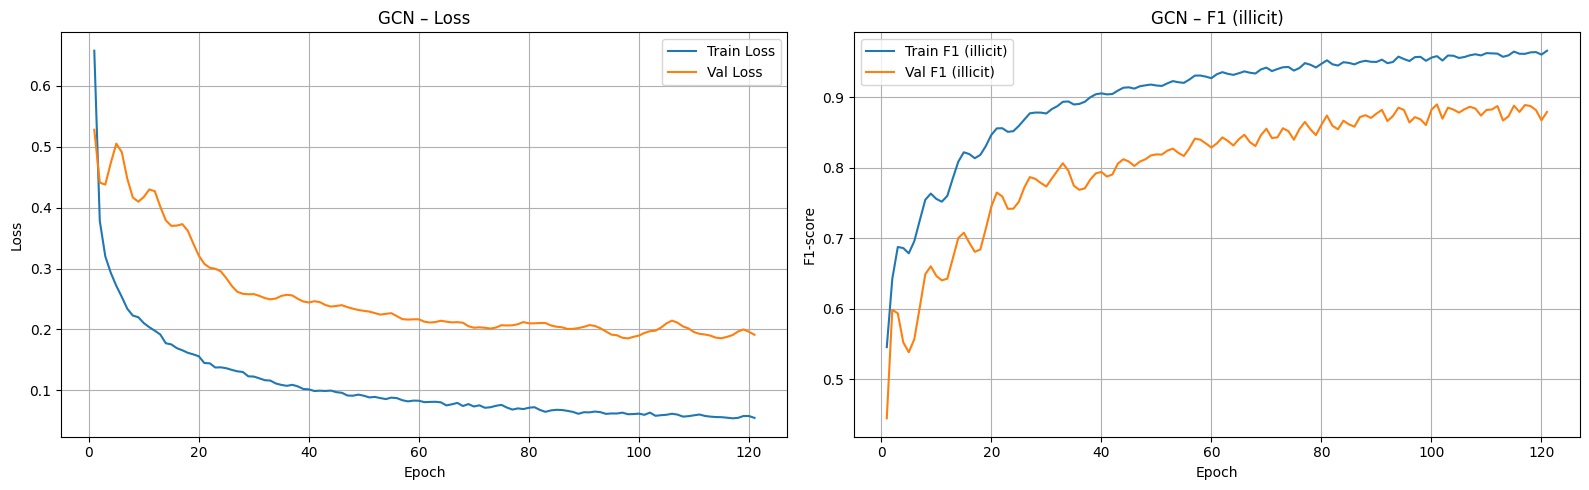

In [7]:
plot_learning_curves(history, model_name="GCN")

#### Test evaluation

In [8]:
model.load_state_dict(torch.load('../saved_models/gcn_best.pt'))
print_test_evaluation(model, data, criterion, label="GCN Test")

 GCN Test Set Evaluation
  Loss          : 0.6981
  Accuracy      : 0.9346
  Precision(ill): 0.4970
  Recall(ill)   : 0.6057
  F1(illicit)   : 0.5460
  F1(macro)     : 0.7554
  AUC-PR        : 0.5487

Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9722    0.9574    0.9647     15587
 Illicit (1)     0.4970    0.6057    0.5460      1083

    accuracy                         0.9346     16670
   macro avg     0.7346    0.7816    0.7554     16670
weighted avg     0.9413    0.9346    0.9375     16670

Confusion Matrix:
[[14923   664]
 [  427   656]]
